<a href="https://colab.research.google.com/github/Cory-Suhr/rush-sales-analysis-final-project/blob/main/rush_sales_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## GB885 Final Project

## Rush Sales Analysis

Cory Suhr

## Business Problem: You work as a sales analyst for RUSH, a globally renowned sportswear and footwear brand known for its innovative designs and performance-oriented products. The company stores its raw sales data as a collection of three tables:

TABLE_PRODUCTS
TABLE_RETAILER
TABLE_SALES
The data includes the number of units sold, the total sales revenue, the location of the sales, the type of product sold, as well as other relevant information. (For data field definitions and explanations, see the data dictionary.) The data is "raw," meaning it has not been cleaned and probably contains errors that need to be addressed.

The VP of US Sales has tasked you with analyzing sales data for trends and insights that will help company leadership understand the market and identify opportunities for growth. For example, you may want to look for trends or insights in seasonality, retailers, locations, or sales methods. Take initiative to apply your creativity and curiosity to this data.

In addition, she has asked you to answer the following business questions:

What product category (product) had the highest sales (in dollars) in 2021? How much did it sell?
What state had the highest sales (in dollars) of women's products in 2021? How much was it?
What state had the highest sales (in dollars) of men's products in 2021? How much was it?
What retailer purchased the most units in 2021? In 2020?

## Import Libraries

In [2]:
# Importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# Loading files from GitHub rather than Google Drive
base_url = (
    'https://raw.githubusercontent.com/'
    'Cory-Suhr/rush-sales-analysis-final-project/'
    'main/'
)

products = pd.read_csv(
    base_url + 'TABLE_PRODUCTS_885.csv',
    sep='|'
)

retailer = pd.read_csv(
    base_url + 'TABLE_RETAILER_885.csv'
)

sales = pd.read_csv(
    base_url + 'TABLE_SALES_885.csv'
)

## Initial Data Inspection

In [4]:
# Looking at some basics for  products

products.head()

,PRODUCT_ID,PRODUCT_NAME
0,20,Men's Street Footwear
1,30,Men's Athletic Footwear
2,120,Women's Street Footwear
3,130,Women's Athletic Footwear
4,40,Men's Apparel


In [5]:
## Products variable types
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   PRODUCT_ID    6 non-null      int64 
 1   PRODUCT_NAME  6 non-null      object
dtypes: int64(1), object(1)
memory usage: 228.0+ bytes


In [6]:
# Basics of retailor
retailer.head()

,RETAILER_ID,RETAILER,REGION,STATE,CITY
0,A00MOHCO,Amazon,Midwest,Ohio,Columbus
1,A00NMAPO,Amazon,Northeast,Maine,Portland
2,A00NMABO,Amazon,Northeast,Massachusetts,Boston
3,A00NNEMA,Amazon,Northeast,New Hampshire,Manchester
4,A00NVEBU,Amazon,Northeast,Vermont,Burlington


In [7]:
# Retailer variable types.
retailer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   RETAILER_ID  110 non-null    object
 1   RETAILER     110 non-null    object
 2   REGION       110 non-null    object
 3   STATE        110 non-null    object
 4   CITY         110 non-null    object
dtypes: object(5)
memory usage: 4.4+ KB


In [8]:
# Sales basics
sales.head()

,ORDER_ID,RETAILER_ID,INVOICE_DATE,MONTH,DAY,YEAR,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES_METHOD
0,1,A00MOHCO,1/1/2020,1,1,2020,20,50.0,1200,0.5,In-store
1,7,A00MOHCO,1/7/2020,1,7,2020,20,50.0,1250,0.5,In-store
2,13,A00MOHCO,1/25/2020,1,25,2020,20,50.0,1220,0.5,Outlet
3,19,A00MOHCO,1/31/2020,1,31,2020,20,50.0,1200,0.5,Outlet
4,25,A00MOHCO,2/6/2020,2,6,2020,20,60.0,1220,0.5,Outlet


In [9]:
# Sales variable types
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9648 entries, 0 to 9647
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDER_ID          9648 non-null   int64  
 1   RETAILER_ID       9648 non-null   object 
 2   INVOICE_DATE      9648 non-null   object 
 3   MONTH             9648 non-null   int64  
 4   DAY               9648 non-null   int64  
 5   YEAR              9648 non-null   int64  
 6   PRODUCT_ID        9648 non-null   int64  
 7   PRICE_PER_UNIT    9646 non-null   float64
 8   UNITS_SOLD        9648 non-null   object 
 9   OPERATING_MARGIN  9648 non-null   float64
 10  SALES_METHOD      9648 non-null   object 
dtypes: float64(2), int64(5), object(4)
memory usage: 829.3+ KB


## Merge the Data Sets

In [10]:
# Merging products and sales
sales_products = pd.merge(sales, products, on='PRODUCT_ID', how='left')

In [11]:
# Checking my work
sales_products.head()

,ORDER_ID,RETAILER_ID,INVOICE_DATE,MONTH,DAY,YEAR,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES_METHOD,PRODUCT_NAME
0,1,A00MOHCO,1/1/2020,1,1,2020,20,50.0,1200,0.5,In-store,Men's Street Footwear
1,7,A00MOHCO,1/7/2020,1,7,2020,20,50.0,1250,0.5,In-store,Men's Street Footwear
2,13,A00MOHCO,1/25/2020,1,25,2020,20,50.0,1220,0.5,Outlet,Men's Street Footwear
3,19,A00MOHCO,1/31/2020,1,31,2020,20,50.0,1200,0.5,Outlet,Men's Street Footwear
4,25,A00MOHCO,2/6/2020,2,6,2020,20,60.0,1220,0.5,Outlet,Men's Street Footwear


In [12]:
# Merging sales_products with retailer
combined_df = pd.merge(sales_products, retailer, on='RETAILER_ID', how='left')

In [13]:
# Check final merger
combined_df.head()

,ORDER_ID,RETAILER_ID,INVOICE_DATE,MONTH,DAY,YEAR,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES_METHOD,PRODUCT_NAME,RETAILER,REGION,STATE,CITY
0,1,A00MOHCO,1/1/2020,1,1,2020,20,50.0,1200,0.5,In-store,Men's Street Footwear,Amazon,Midwest,Ohio,Columbus
1,7,A00MOHCO,1/7/2020,1,7,2020,20,50.0,1250,0.5,In-store,Men's Street Footwear,Amazon,Midwest,Ohio,Columbus
2,13,A00MOHCO,1/25/2020,1,25,2020,20,50.0,1220,0.5,Outlet,Men's Street Footwear,Amazon,Midwest,Ohio,Columbus
3,19,A00MOHCO,1/31/2020,1,31,2020,20,50.0,1200,0.5,Outlet,Men's Street Footwear,Amazon,Midwest,Ohio,Columbus
4,25,A00MOHCO,2/6/2020,2,6,2020,20,60.0,1220,0.5,Outlet,Men's Street Footwear,Amazon,Midwest,Ohio,Columbus


## Looking at the combined dataset for some basics:
Month, Day and Year could be deleted once invoice date is converted to datetime


*   Units sold should be numeric
*   PRICE_PER unit 2 null values
* Retailer, Region, State and City each have 1 null (Drop this row.)
* Sales_Method has 'Oolet' that shoule be 'Outlet'
* PRICE_PER_UNIT has 99999
*



In [14]:
# Looking at the variable types
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10271 entries, 0 to 10270
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDER_ID          10271 non-null  int64  
 1   RETAILER_ID       10271 non-null  object 
 2   INVOICE_DATE      10271 non-null  object 
 3   MONTH             10271 non-null  int64  
 4   DAY               10271 non-null  int64  
 5   YEAR              10271 non-null  int64  
 6   PRODUCT_ID        10271 non-null  int64  
 7   PRICE_PER_UNIT    10269 non-null  float64
 8   UNITS_SOLD        10271 non-null  object 
 9   OPERATING_MARGIN  10271 non-null  float64
 10  SALES_METHOD      10271 non-null  object 
 11  PRODUCT_NAME      10271 non-null  object 
 12  RETAILER          10270 non-null  object 
 13  REGION            10270 non-null  object 
 14  STATE             10270 non-null  object 
 15  CITY              10270 non-null  object 
dtypes: float64(2), int64(5), object(9)
memor

In [15]:
# Further looks
combined_df.describe()

,ORDER_ID,MONTH,DAY,YEAR,PRODUCT_ID,PRICE_PER_UNIT,OPERATING_MARGIN
count,10271.000000,10271.000000,10271.000000,10271.000000,10271.000000,10269.000000,10271.000000
mean,4970.630903,6.456333,14.620290,2020.873235,80.001947,54.575324,0.426380
std,2770.737186,3.461826,7.301233,0.332725,50.671441,986.473924,0.096018
min,1.000000,1.000000,1.000000,2020.000000,20.000000,7.000000,0.100000
25%,2568.500000,3.000000,9.000000,2021.000000,30.000000,35.000000,0.350000
50%,5136.000000,6.000000,14.000000,2021.000000,120.000000,45.000000,0.420000
75%,7236.000000,9.000000,20.000000,2021.000000,130.000000,55.000000,0.500000
max,9648.000000,12.000000,31.000000,2021.000000,140.000000,99999.000000,0.800000


In [16]:
# Looking for null values
combined_df.isnull().sum()

,0
ORDER_ID,0
RETAILER_ID,0
INVOICE_DATE,0
MONTH,0
DAY,0
YEAR,0
PRODUCT_ID,0
PRICE_PER_UNIT,2
UNITS_SOLD,0
OPERATING_MARGIN,0


In [17]:
# Looking at the rows with null values for PRICE_PER_UNIT
combined_df[combined_df['PRICE_PER_UNIT'].isnull()]


,ORDER_ID,RETAILER_ID,INVOICE_DATE,MONTH,DAY,YEAR,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES_METHOD,PRODUCT_NAME,RETAILER,REGION,STATE,CITY
98,591,A00NVEBU,4/2/2020,4,2,2020,20,NaN,525,0.35,In-store,Men's Street Footwear,Amazon,Northeast,Vermont,Burlington
99,597,A00NVEBU,4/8/2020,4,8,2020,20,NaN,525,0.50,In-store,Men's Street Footwear,Amazon,Northeast,Vermont,Burlington


In [18]:
# Looking at null values for RETAILER
combined_df[combined_df['RETAILER'].isnull()]

,ORDER_ID,RETAILER_ID,INVOICE_DATE,MONTH,DAY,YEAR,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES_METHOD,PRODUCT_NAME,RETAILER,REGION,STATE,CITY
1534,8668,999999999,7/23/2021,7,23,2021,20,60.0,298,0.42,Outlet,Men's Street Footwear,NaN,NaN,NaN,NaN


In [19]:
# Verifying there this is the only entry with the RETAILER_ID with 999999999
combined_df[combined_df['RETAILER_ID'] == '999999999']

,ORDER_ID,RETAILER_ID,INVOICE_DATE,MONTH,DAY,YEAR,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES_METHOD,PRODUCT_NAME,RETAILER,REGION,STATE,CITY
1534,8668,999999999,7/23/2021,7,23,2021,20,60.0,298,0.42,Outlet,Men's Street Footwear,NaN,NaN,NaN,NaN


# With the null values in Retailer, region, state and city. And no way to determine the retailer based on the retailer ID going to drop this row from the dataframe

In [20]:
# Dropping row with index 1534
combind_df = combined_df.drop(index=1534)

In [21]:
# Looking for Non_traditional categorical data
cat_var = list(combined_df.select_dtypes(include=['object']).columns)
# View unique values for each categorical variable
for column in cat_var:
    print(column)
    print(combined_df[column].unique())


RETAILER_ID
['A00MOHCO' 'A00NMAPO' 'A00NMABO' 'A00NNEMA' 'A00NVEBU' 'A00SALBI'
 'A00SKELO' 'A00SNOCH' 'A00WALAN' 'F00SLONE' 'F00SGEAT' 'F00SVIRI'
 'F00WALAN' 'F00WARPH' 'F00WHAHO' 'F00MNEOM' 'F00WIDBO' 'F00WWYCH'
 'F00MILCH' 'F00MIODE' 'F00MKAWI' 'F00MMIDE' 'F00MMIMI' 'F00MMIST'
 'F00MNOFA' 'F00MSOSI' 'F00NCOHA' 'F00NDEWI' 'F00NMABA' 'F00NNEMA'
 'F00SFLMI' 'F00NNENE' 'F00NPEPH' 'F00SKELO' 'F00NRHPR' 'F00SSOCH'
 'F00NWECH' 'F00SMIJA' 'F00STEKN' 'F00STEDA' 'F00WCALO' 'F00WWASE'
 'K00WARPH' 'K00WNEAL' 'K00NDEWI' 'K00NNENE' 'K00NNEAL' 'K00WWYCH'
 'K00MMIMI' 'K00MMOBI' 'K00WCALO' 'K00WCASA' 'K00MKAWI' 'K00SOKOK'
 'S00MILCH' 'S00SFLOR' 'S00SGEAT' 'S00MMOBI' 'S00SVIRI' 'S00MNEOM'
 'S00WHAHO' 'S00WNEAL' 'S00MMIDE' 'S00MNOFA' 'S00MSOSI' 'S00NCOHA'
 'S00NMABA' 'S00NNENE' 'S00NMABO' 'S00NRHPR' 'S00SMIJA' 'S00SFLMI'
 'S00SNOCH' 'S00SSOCH' 'S00SALBI' 'S00STEKN' 'S00STEDA' 'S00STEHO'
 'S00WIDBO' 'W00SFLOR' 'W00WHAHO' 'W00NNENE' 'W00SMIJA' 'W00SARLI'
 'W00STEHO' 'W00NMAPO' 'W00NPEPH' 'W00SLONE' 'W00W

# Look for Duplicate Values

In [22]:
# Checking for duplicates
combined_df.duplicated().sum()

np.int64(0)

# Check for Erroneous Data

In [23]:
# Check for vaule count of erroneous data
# List of categorical variables
cat_var = list(combined_df.select_dtypes(include=['object']).columns)

# Loop through each categorical variable and print the value counts
for column in cat_var:
    print(column)
    print(combined_df[[column]].value_counts())


RETAILER_ID
RETAILER_ID
W00SARLI       432
W00SFLOR       378
W00STEHO       324
W00WORPO       216
W00WUTSA       216
              ... 
S00MNEOM         8
W00MOHCO         8
S00MILCH         8
W00NMAPO         8
999999999        1
Name: count, Length: 107, dtype: int64
INVOICE_DATE
INVOICE_DATE
1/17/2021       88
11/17/2021      83
12/16/2021      81
1/10/2021       80
4/17/2021       79
                ..
10/10/2020       2
10/2/2020        2
10/1/2020        2
9/18/2020        2
9/19/2020        2
Name: count, Length: 724, dtype: int64
UNITS_SOLD
UNITS_SOLD
150           210
225           209
175           192
300           189
200           175
             ... 
185             1
720             1
695             1
645             1
1020            1
Name: count, Length: 362, dtype: int64
SALES_METHOD
SALES_METHOD
Online          5417
Outlet          3094
In-store        1740
Ootlet            20
Name: count, dtype: int64
PRODUCT_NAME
PRODUCT_NAME             
Men's Athletic Footw

# Look for Outliers Using the Inner Quantile Ranges (IQR)

In [24]:
# Write a function to calculate the IQR and print rows with values that fall outside that IQR

def count_iqr_outliers(df, column):
  #define q1
  q1 = df[column].quantile(0.25)
  #define q3
  q3 = df[column].quantile(0.75)
  # define iqr
  iqr = q3- q1
  # define the threshold
  l_threshold = q1 - 1.5 * iqr
  u_threshold = q3 + 1.5 * iqr
  # define outliers
  outliers = (df[column] < l_threshold) | (df[column] > u_threshold)
  # Count the number of True values (outliers)
  return outliers.sum()

In [25]:
# iterate over the numerical columns of the dataframe
num_var = list(combined_df.select_dtypes(include=['int64', 'float64']).columns)

for column in num_var:
    print(f'{column} : {count_iqr_outliers(combined_df, column)}')

ORDER_ID : 0
MONTH : 0
DAY : 0
YEAR : 1302
PRODUCT_ID : 0
PRICE_PER_UNIT : 85
OPERATING_MARGIN : 31


In [26]:
# Looking into outliers
count_iqr_outliers(combined_df, 'PRICE_PER_UNIT')

np.int64(85)

## Data Cleaning
-Convert UNITS_SOLD to numeris
- Replace 2 null values in PRICE_PER_UNIT
-Replace the 99999 in PRICE_PER_UNIT
- Replace 'Oolet' with 'Outlet'

In [27]:
# Converting Units Sold to numeric
combined_df['UNITS_SOLD'] = pd.to_numeric(combined_df['UNITS_SOLD'], errors='coerce')

In [28]:
# Convert Invoice date to datetime
combined_df['INVOICE_DATE'] = pd.to_datetime(combined_df['INVOICE_DATE'])

In [29]:
# Checking my work
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10271 entries, 0 to 10270
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   ORDER_ID          10271 non-null  int64         
 1   RETAILER_ID       10271 non-null  object        
 2   INVOICE_DATE      10271 non-null  datetime64[ns]
 3   MONTH             10271 non-null  int64         
 4   DAY               10271 non-null  int64         
 5   YEAR              10271 non-null  int64         
 6   PRODUCT_ID        10271 non-null  int64         
 7   PRICE_PER_UNIT    10269 non-null  float64       
 8   UNITS_SOLD        10269 non-null  float64       
 9   OPERATING_MARGIN  10271 non-null  float64       
 10  SALES_METHOD      10271 non-null  object        
 11  PRODUCT_NAME      10271 non-null  object        
 12  RETAILER          10270 non-null  object        
 13  REGION            10270 non-null  object        
 14  STATE             1027

In [30]:
# Drop Month, Day and Year columns as they provide duplicated information contained in the invoice date
combined_df = combined_df.drop(columns=['MONTH', 'DAY', 'YEAR'])

In [31]:
# Checking myy work
combined_df.head()

,ORDER_ID,RETAILER_ID,INVOICE_DATE,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES_METHOD,PRODUCT_NAME,RETAILER,REGION,STATE,CITY
0,1,A00MOHCO,2020-01-01,20,50.0,1200.0,0.5,In-store,Men's Street Footwear,Amazon,Midwest,Ohio,Columbus
1,7,A00MOHCO,2020-01-07,20,50.0,1250.0,0.5,In-store,Men's Street Footwear,Amazon,Midwest,Ohio,Columbus
2,13,A00MOHCO,2020-01-25,20,50.0,1220.0,0.5,Outlet,Men's Street Footwear,Amazon,Midwest,Ohio,Columbus
3,19,A00MOHCO,2020-01-31,20,50.0,1200.0,0.5,Outlet,Men's Street Footwear,Amazon,Midwest,Ohio,Columbus
4,25,A00MOHCO,2020-02-06,20,60.0,1220.0,0.5,Outlet,Men's Street Footwear,Amazon,Midwest,Ohio,Columbus


## All null values and the 99999 value in price per unit are with product 20. find the median and mean price for the product and replace the null and erroneous values

In [32]:
# Finding mean and median for product ID 20
mean_price = combined_df[combined_df['PRODUCT_ID'] == 20]['PRICE_PER_UNIT'].mean()
median_price = combined_df[combined_df['PRODUCT_ID'] == 20]['PRICE_PER_UNIT'].median()

print(mean_price)
print(median_price)

102.38924605493864
44.0


## It seems the 99999 is skewing the mean. I will use the median to repalce the null values and the 99999

In [33]:
# Replacing null values in price per unit with 44.0

combined_df['PRICE_PER_UNIT'] = combined_df['PRICE_PER_UNIT'].fillna(44.0)

In [34]:
 # Replacing 99999 with the median of 44.0
combined_df['PRICE_PER_UNIT'] = combined_df['PRICE_PER_UNIT'].replace(99999.000000, 44.0)

## Replacing the 'Ootlet' with 'Oulet'

In [35]:
# Replace sales method Ootlet with Oulet
combined_df['SALES_METHOD'] = combined_df['SALES_METHOD'].replace('Ootlet', 'Outlet')

In [36]:
# Checking my work
combined_df.describe()

,ORDER_ID,INVOICE_DATE,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN
count,10271.000000,10271,10271.000000,10271.000000,10269.000000,10271.000000
mean,4970.630903,2021-05-13 12:00:54.678220288,80.001947,44.841495,246.638232,0.426380
min,1.000000,2020-01-01 00:00:00,20.000000,7.000000,0.000000,0.100000
25%,2568.500000,2021-02-18 00:00:00,30.000000,35.000000,100.000000,0.350000
50%,5136.000000,2021-06-05 00:00:00,120.000000,45.000000,173.000000,0.420000
75%,7236.000000,2021-09-17 00:00:00,130.000000,55.000000,325.000000,0.500000
max,9648.000000,2021-12-31 00:00:00,140.000000,110.000000,1275.000000,0.800000
std,2770.737186,NaN,50.671441,14.789144,211.881078,0.096018


In [37]:
# Checking all variable for sales method
combined_df['SALES_METHOD'].unique()

array(['In-store', 'Outlet', 'Online'], dtype=object)

In [38]:
# Double cheking for null values
combined_df.isnull().sum()

,0
ORDER_ID,0
RETAILER_ID,0
INVOICE_DATE,0
PRODUCT_ID,0
PRICE_PER_UNIT,0
UNITS_SOLD,2
OPERATING_MARGIN,0
SALES_METHOD,0
PRODUCT_NAME,0
RETAILER,1


In [39]:
# Looking at the null values
combined_df[combined_df['RETAILER'].isnull()]

,ORDER_ID,RETAILER_ID,INVOICE_DATE,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES_METHOD,PRODUCT_NAME,RETAILER,REGION,STATE,CITY
1534,8668,999999999,2021-07-23,20,60.0,298.0,0.42,Outlet,Men's Street Footwear,NaN,NaN,NaN,NaN


In [40]:
# Dropping index 1534 again
combined_df = combined_df.drop(index=1534)

In [41]:
# Checking for null values
combined_df.isnull().sum()

,0
ORDER_ID,0
RETAILER_ID,0
INVOICE_DATE,0
PRODUCT_ID,0
PRICE_PER_UNIT,0
UNITS_SOLD,2
OPERATING_MARGIN,0
SALES_METHOD,0
PRODUCT_NAME,0
RETAILER,0


## Exploratory Data Analysis

In [42]:
# Exploring the cleaned data
combined_df.describe()

,ORDER_ID,INVOICE_DATE,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN
count,10270.000000,10270,10270.000000,10270.000000,10268.000000,10270.000000
mean,4970.270886,2021-05-13 11:51:01.577410048,80.007790,44.840019,246.633229,0.426381
min,1.000000,2020-01-01 00:00:00,20.000000,7.000000,0.000000,0.100000
25%,2568.250000,2021-02-18 00:00:00,30.000000,35.000000,100.000000,0.350000
50%,5135.500000,2021-06-05 00:00:00,120.000000,45.000000,173.000000,0.420000
75%,7235.750000,2021-09-17 00:00:00,130.000000,55.000000,325.000000,0.500000
max,9648.000000,2021-12-31 00:00:00,140.000000,110.000000,1275.000000,0.800000
std,2770.631835,NaN,50.670448,14.789108,211.890790,0.096023


In [43]:
combined_df.select_dtypes(include=['number']).corr()

,ORDER_ID,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN
ORDER_ID,1.000000,0.001069,-0.316185,-0.679888,0.329505
PRODUCT_ID,0.001069,1.000000,-0.024348,-0.113255,0.022810
PRICE_PER_UNIT,-0.316185,-0.024348,1.000000,0.274148,-0.139442
UNITS_SOLD,-0.679888,-0.113255,0.274148,1.000000,-0.319389
OPERATING_MARGIN,0.329505,0.022810,-0.139442,-0.319389,1.000000


## VP Business Questions:
The VP of US Sales has tasked you with analyzing sales data for trends and insights that will help company leadership understand the market and identify opportunities for growth. For example, you may want to look for trends or insights in seasonality, retailers, locations, or sales methods. Take initiative to apply your creativity and curiosity to this data.

In addition, she has asked you to answer the following business questions:

What product category (product) had the highest sales (in dollars) in 2021? How much did it sell?
What state had the highest sales (in dollars) of women's products in 2021? How much was it?
What state had the highest sales (in dollars) of men's products in 2021? How much was it?
What retailer purchased the most units in 2021? In 2020?

In [44]:
# Starting with creating a 'REVENUE' column
combined_df['REVENUE'] = combined_df['UNITS_SOLD'] * combined_df['PRICE_PER_UNIT']

In [45]:
# Looking at the new column
combined_df.head()

,ORDER_ID,RETAILER_ID,INVOICE_DATE,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES_METHOD,PRODUCT_NAME,RETAILER,REGION,STATE,CITY,REVENUE
0,1,A00MOHCO,2020-01-01,20,50.0,1200.0,0.5,In-store,Men's Street Footwear,Amazon,Midwest,Ohio,Columbus,60000.0
1,7,A00MOHCO,2020-01-07,20,50.0,1250.0,0.5,In-store,Men's Street Footwear,Amazon,Midwest,Ohio,Columbus,62500.0
2,13,A00MOHCO,2020-01-25,20,50.0,1220.0,0.5,Outlet,Men's Street Footwear,Amazon,Midwest,Ohio,Columbus,61000.0
3,19,A00MOHCO,2020-01-31,20,50.0,1200.0,0.5,Outlet,Men's Street Footwear,Amazon,Midwest,Ohio,Columbus,60000.0
4,25,A00MOHCO,2020-02-06,20,60.0,1220.0,0.5,Outlet,Men's Street Footwear,Amazon,Midwest,Ohio,Columbus,73200.0


## Looking to see which Retailer had the most revenue

In [46]:
# Revenue by Retailer
combined_df.groupby('RETAILER')['REVENUE'].sum().sort_values(ascending=False)

,REVENUE
RETAILER,
Foot Locker,53643305.0
Amazon,28008825.0
West Gear,14584306.0
Sports Direct,13031410.0
Kohl's,10852813.0
Walmart,2256523.0


In [47]:
# Revue by Region
combined_df.groupby('REGION')['REVENUE'].sum().sort_values(ascending=False)

,REVENUE
REGION,
Northeast,39316504.0
Midwest,31433570.0
West,24820550.0
Southeast,15356136.0
South,11450422.0


# Looking at Question 1 What product category (product) had the highest sales (in dollars) in 2021? How much did it sell?

In [48]:
# Looking at 2021
sales_2021 = combined_df[combined_df['INVOICE_DATE'].dt.year == 2021]

In [49]:
# Grouping by the product name
sales_2021.groupby('PRODUCT_NAME')['REVENUE'].sum().sort_values(ascending=False)

,REVENUE
PRODUCT_NAME,
Men's Street Footwear,23280236.0
Women's Apparel,19658904.0
Men's Athletic Footwear,16702706.0
Women's Street Footwear,13807909.0
Men's Apparel,13325861.0
Women's Athletic Footwear,11381041.0


## Question 2: What state had the highest sales (in dollars) of women's products in 2021? How much was it?

In [50]:
# Filtering by women's products
womens_2021 = sales_2021['PRODUCT_NAME'].str.startswith("Women's")

In [51]:
# Grouping by state to find the highest sales
state_sales = sales_2021[womens_2021].groupby('STATE')['REVENUE'].sum().sort_values(ascending=False)
state_sales.head(1)

,REVENUE
STATE,
Maine,2176301.0


## Question 3: What state had the highest sales (in dollars) of men's products in 2021? How much was it?

In [52]:
# Looking at men'd products in 2021
mens_2021 = sales_2021['PRODUCT_NAME'].str.startswith("Men's")

In [53]:
# Grouping men's product revenue by state
mens_state_sales = sales_2021[mens_2021].groupby('STATE')['REVENUE'].sum().sort_values(ascending=False)
mens_state_sales.head(1)

,REVENUE
STATE,
Delaware,2334300.0


## Question 4: What retailer purchased the most units in 2021? In 2020?

In [54]:
# Looking at 2020
sales_2020 = combined_df[combined_df['INVOICE_DATE'].dt.year == 2020]

In [55]:
# Grouping 2021 by retailer
retailer_2021 = sales_2021.groupby('RETAILER')['UNITS_SOLD'].sum().sort_values(ascending=False)
retailer_2021.head(1)

,UNITS_SOLD
RETAILER,
Foot Locker,1097410.0


In [56]:
# Grouping 2020 by retailer
retailer_2020 = sales_2020.groupby('RETAILER')['UNITS_SOLD'].sum().sort_values(ascending=False)
retailer_2020.head(1)

,UNITS_SOLD
RETAILER,
Amazon,317930.0


In [57]:
# stopping
combined_df.head()

,ORDER_ID,RETAILER_ID,INVOICE_DATE,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES_METHOD,PRODUCT_NAME,RETAILER,REGION,STATE,CITY,REVENUE
0,1,A00MOHCO,2020-01-01,20,50.0,1200.0,0.5,In-store,Men's Street Footwear,Amazon,Midwest,Ohio,Columbus,60000.0
1,7,A00MOHCO,2020-01-07,20,50.0,1250.0,0.5,In-store,Men's Street Footwear,Amazon,Midwest,Ohio,Columbus,62500.0
2,13,A00MOHCO,2020-01-25,20,50.0,1220.0,0.5,Outlet,Men's Street Footwear,Amazon,Midwest,Ohio,Columbus,61000.0
3,19,A00MOHCO,2020-01-31,20,50.0,1200.0,0.5,Outlet,Men's Street Footwear,Amazon,Midwest,Ohio,Columbus,60000.0
4,25,A00MOHCO,2020-02-06,20,60.0,1220.0,0.5,Outlet,Men's Street Footwear,Amazon,Midwest,Ohio,Columbus,73200.0


## Looking at some other insights that could prove worth while for the presentaion.

In [58]:
# Looking year over year sales data starting with revenue by retailer
retailer_yoy = pd.pivot_table(combined_df,
                              index = 'RETAILER',
                              columns=combined_df['INVOICE_DATE'].dt.year,
                              values='REVENUE',
                              aggfunc='sum')
retailer_yoy


INVOICE_DATE,2020,2021
RETAILER,,
Amazon,17521350.0,10487475.0
Foot Locker,NaN,53643305.0
Kohl's,3618731.0,7234082.0
Sports Direct,901235.0,12130175.0
Walmart,NaN,2256523.0
West Gear,2179209.0,12405097.0


## Was not expecting Null values. Need some further investigating

In [59]:
# Looking at retailers and year
combined_df.groupby(combined_df['INVOICE_DATE'].dt.year)['RETAILER'].value_counts()

INVOICE_DATE  RETAILER     
2020          Amazon            530
              Kohl's            394
              West Gear         242
              Sports Direct     136
2021          Foot Locker      2637
              West Gear        2581
              Sports Direct    1952
              Walmart           743
              Kohl's            636
              Amazon            419
Name: count, dtype: int64

In [60]:
# Looking at retailers with null values
combined_df[combined_df['RETAILER'] == 'Foot Locker']['INVOICE_DATE'].dt.year.value_counts()

,count
INVOICE_DATE,
2021,2637


In [61]:
# Looking at Wal Mart
combined_df[combined_df['RETAILER'] == 'Walmart']['INVOICE_DATE'].dt.year.value_counts()

,count
INVOICE_DATE,
2021,743


In [62]:
# Looking at total revenue year over year
combined_df.groupby(combined_df['INVOICE_DATE'].dt.year)['REVENUE'].sum()

,REVENUE
INVOICE_DATE,
2020,24220525.0
2021,98156657.0


## Footlocker and Walmart are new retailers added for 2021.

## To show retailer growth year over year will need to drop Foot Locker and Walmart for that table

In [63]:
# Remove retailers that weren't present in both years
retailer_growth = retailer_yoy.dropna().copy()

retailer_growth

INVOICE_DATE,2020,2021
RETAILER,,
Amazon,17521350.0,10487475.0
Kohl's,3618731.0,7234082.0
Sports Direct,901235.0,12130175.0
West Gear,2179209.0,12405097.0


In [64]:
retailer_growth['Growth (%)'] = round((retailer_growth[2021] - retailer_growth[2020]) / retailer_growth[2020] * 100, 2)

# Sort by growth
retailer_growth.sort_values(by='Growth (%)', ascending=False)

INVOICE_DATE,2020,2021,Growth (%)
RETAILER,,,
Sports Direct,901235.0,12130175.0,1245.95
West Gear,2179209.0,12405097.0,469.25
Kohl's,3618731.0,7234082.0,99.91
Amazon,17521350.0,10487475.0,-40.14


## Lookig year over year product sales $

In [65]:
# Looking at year over year product revenue
product_yoy = pd.pivot_table(combined_df,
                              index = 'PRODUCT_NAME',
                              columns=combined_df['INVOICE_DATE'].dt.year,
                              values='REVENUE',
                              aggfunc='sum')
product_yoy

INVOICE_DATE,2020,2021
PRODUCT_NAME,,
Men's Apparel,3495339.0,13325861.0
Men's Athletic Footwear,4237587.0,16702706.0
Men's Street Footwear,4974220.0,23280236.0
Women's Apparel,4692707.0,19658904.0
Women's Athletic Footwear,3154892.0,11381041.0
Women's Street Footwear,3665780.0,13807909.0


In [66]:
# Calculate dollar growth
product_yoy['Growth ($)'] = (product_yoy[2021] - product_yoy[2020])

# Sort by growth
product_yoy.sort_values(by='Growth ($)', ascending=False)

INVOICE_DATE,2020,2021,Growth ($)
PRODUCT_NAME,,,
Men's Street Footwear,4974220.0,23280236.0,18306016.0
Women's Apparel,4692707.0,19658904.0,14966197.0
Men's Athletic Footwear,4237587.0,16702706.0,12465119.0
Women's Street Footwear,3665780.0,13807909.0,10142129.0
Men's Apparel,3495339.0,13325861.0,9830522.0
Women's Athletic Footwear,3154892.0,11381041.0,8226149.0


In [67]:
# Calculate dollar growth %
product_yoy['Growth (%)'] = round((product_yoy[2021] - product_yoy[2020]) / product_yoy[2020] * 100, 2)

# Sort by growth
product_yoy.sort_values(by='Growth (%)', ascending=False)

INVOICE_DATE,2020,2021,Growth ($),Growth (%)
PRODUCT_NAME,,,,
Men's Street Footwear,4974220.0,23280236.0,18306016.0,368.02
Women's Apparel,4692707.0,19658904.0,14966197.0,318.92
Men's Athletic Footwear,4237587.0,16702706.0,12465119.0,294.16
Men's Apparel,3495339.0,13325861.0,9830522.0,281.25
Women's Street Footwear,3665780.0,13807909.0,10142129.0,276.67
Women's Athletic Footwear,3154892.0,11381041.0,8226149.0,260.74


In [68]:
# Calculate over all year over year revenue growth
combined_df.groupby(combined_df['INVOICE_DATE'].dt.year)['REVENUE'].sum()

,REVENUE
INVOICE_DATE,
2020,24220525.0
2021,98156657.0


In [69]:
# Calculate overall dollar growth
combined_df.groupby(combined_df['INVOICE_DATE'].dt.year)['REVENUE'].sum().pct_change() * 100

,REVENUE
INVOICE_DATE,
2020,NaN
2021,305.262301


## Impressive growth was 2020 only a partial year?

In [70]:
# Looking at the date range
combined_df['INVOICE_DATE'].min(), combined_df['INVOICE_DATE'].max()

(Timestamp('2020-01-01 00:00:00'), Timestamp('2021-12-31 00:00:00'))

In [71]:
# Looking at revenue by retailer and product for 2021
retailer_product = pd.pivot_table(
    sales_2021,
    index = 'RETAILER',
    columns = 'PRODUCT_NAME',
    values ='REVENUE',
    aggfunc ='sum'
)
retailer_product

PRODUCT_NAME,Men's Apparel,Men's Athletic Footwear,Men's Street Footwear,Women's Apparel,Women's Athletic Footwear,Women's Street Footwear
RETAILER,,,,,,
Amazon,1415000.0,1920750.0,2133275.0,2068750.0,1329250.0,1620450.0
Foot Locker,7347500.0,9034125.0,12892880.0,10783750.0,6158125.0,7426925.0
Kohl's,930142.0,1181110.0,1919848.0,1444432.0,786834.0,971716.0
Sports Direct,1685186.0,2128126.0,2689326.0,2365794.0,1483274.0,1778469.0
Walmart,292204.0,333107.0,689527.0,495720.0,200499.0,245466.0
West Gear,1655829.0,2105488.0,2955380.0,2500458.0,1423059.0,1764883.0


In [72]:
# Convert each retailer's product sales to a percentage of its total sales
retailer_product_pct = (retailer_product.div(retailer_product.sum(axis =1 ), axis=0) *100).round(1)

retailer_product_pct

PRODUCT_NAME,Men's Apparel,Men's Athletic Footwear,Men's Street Footwear,Women's Apparel,Women's Athletic Footwear,Women's Street Footwear
RETAILER,,,,,,
Amazon,13.5,18.3,20.3,19.7,12.7,15.5
Foot Locker,13.7,16.8,24.0,20.1,11.5,13.8
Kohl's,12.9,16.3,26.5,20.0,10.9,13.4
Sports Direct,13.9,17.5,22.2,19.5,12.2,14.7
Walmart,12.9,14.8,30.6,22.0,8.9,10.9
West Gear,13.3,17.0,23.8,20.2,11.5,14.2


## Visualizations.
1. Revenue by Product (2021)
2. Product Growth (2020 - to 2021)
3. Retailer Revenue Growth
4. Retailer Reveenue (2020 vs 2021)
5. Retailer Product Mix
6. State Revenue

In [73]:
# create product_sales
product_sales = (sales_2021.groupby('PRODUCT_NAME')['REVENUE'].sum().sort_values(ascending=False))
product_sales

,REVENUE
PRODUCT_NAME,
Men's Street Footwear,23280236.0
Women's Apparel,19658904.0
Men's Athletic Footwear,16702706.0
Women's Street Footwear,13807909.0
Men's Apparel,13325861.0
Women's Athletic Footwear,11381041.0


In [74]:
# Bring in formatter to format axis
from matplotlib.ticker import FuncFormatter



## Need to create folders in Colab and Github to store chart images for the presentation

In [75]:
# Create an images folder in Colab
import os

os.makedirs('images', exist_ok=True)

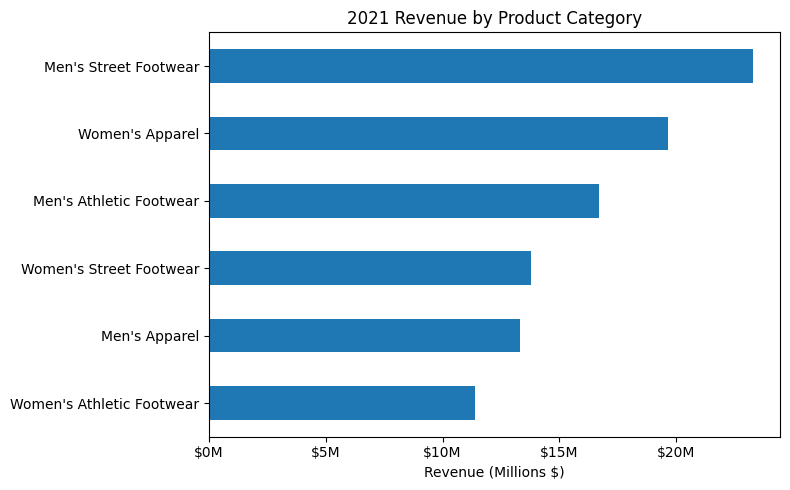

In [76]:
# Chart 1 revenue by product 2021 Horizontal bar chart
product_sales.sort_values().plot(
    kind='barh',
    figsize=(8,5)
)

plt.title('2021 Revenue by Product Category')
plt.xlabel('Revenue (Millions $)')
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'${x/1_000_000:.0f}M'))
plt.ylabel('')
plt.tight_layout()
plt.savefig('images/chart1_product_revenue_2021.png', dpi=300, bbox_inches='tight')
plt.show()

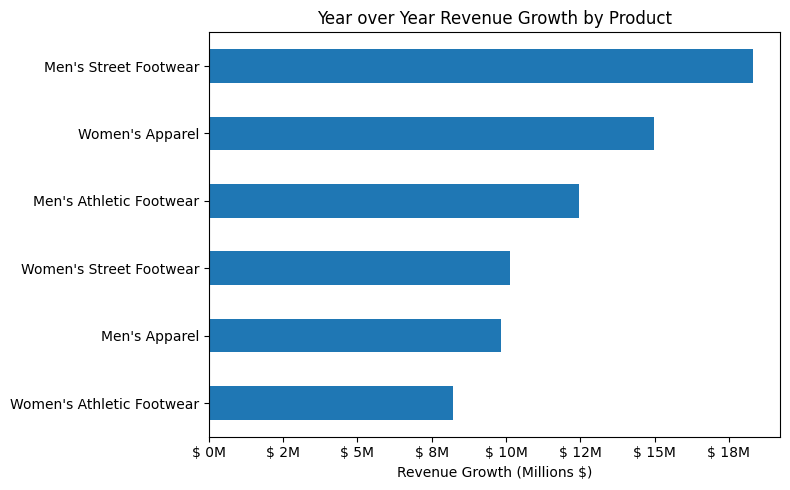

In [77]:
# Chart 2 product growth 2020 to 2021 horizontal bar chart
product_yoy['Growth ($)'].sort_values().plot(
    kind='barh',
    figsize=(8,5)
)

plt.title('Year over Year Revenue Growth by Product')
plt.xlabel('Revenue Growth (Millions $)')
plt.ylabel('')
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'${x/1_000_000: .0f}M'))
plt.tight_layout()
plt.savefig('images/chart2_product_growth.png', dpi=300, bbox_inches='tight')
plt.show()

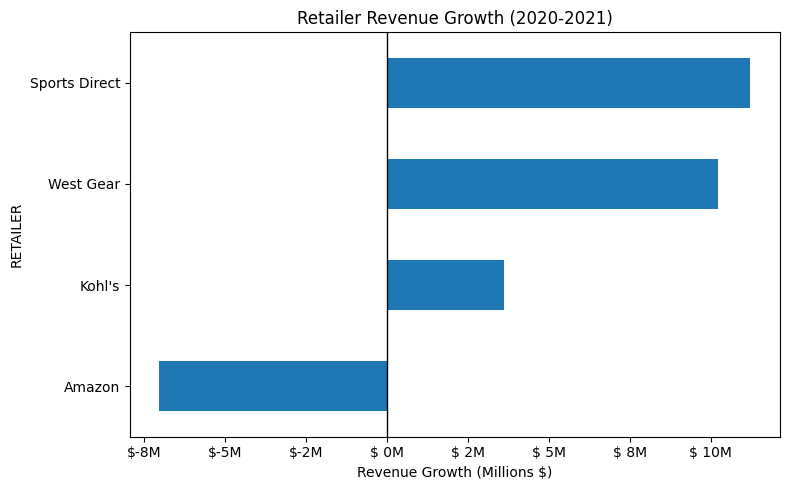

In [78]:
# Chart 3 Retailer Revenue Growth
retailer_growth['Growth ($)'] = (retailer_growth[2021] - retailer_growth[2020])
retailer_growth['Growth ($)'].sort_values().plot(
    kind='barh',
    figsize=(8,5)
)

plt.title('Retailer Revenue Growth (2020-2021)')
plt.xlabel('Revenue Growth (Millions $)')
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'${x/1_000_000: .0f}M'))
plt.axvline(x=0, color='black', linewidth=1)
plt.tight_layout()
plt.savefig('images/chart3_retailer_revenue_growth.png', dpi=300, bbox_inches='tight')
plt.show()

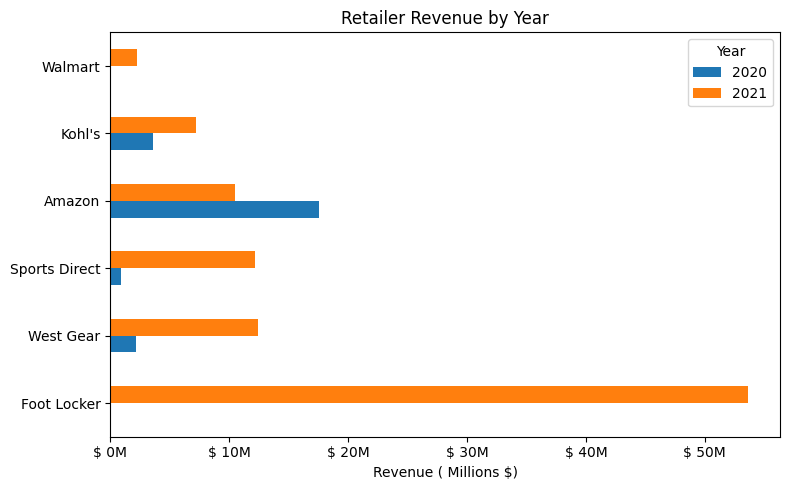

In [79]:
# Chart 4 Retailer Revenue (2020 vs 2021)
retailer_yoy = retailer_yoy.sort_values(by=2021, ascending=False)
retailer_yoy.plot(
    kind='barh',
    figsize=(8,5)
)

plt.title('Retailer Revenue by Year')
plt.xlabel('Revenue ( Millions $)')
plt.ylabel('')
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'${x/1_000_000: .0f}M'))
plt.legend(title= 'Year')
plt.tight_layout()
plt.savefig('images/chart4_retailer_revenue_by_year.png', dpi=300, bbox_inches='tight')
plt.show()

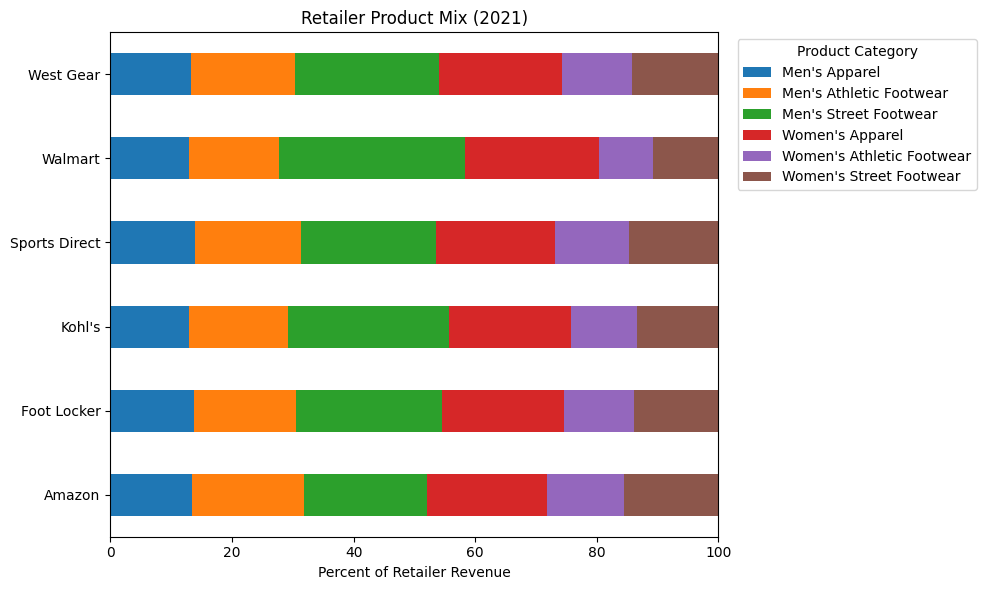

In [80]:
# Chart 5 retailer Product Mix
ax = retailer_product_pct.plot(
    kind='barh',
    stacked=True,
    figsize=(10,6)
)

plt.title('Retailer Product Mix (2021)')
plt.xlabel('Percent of Retailer Revenue')
plt.ylabel('')
plt.xlim(0, 100)
plt.legend(title='Product Category', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('images/chart5_retailer_product_mix.png', dpi=300, bbox_inches='tight')
plt.show()

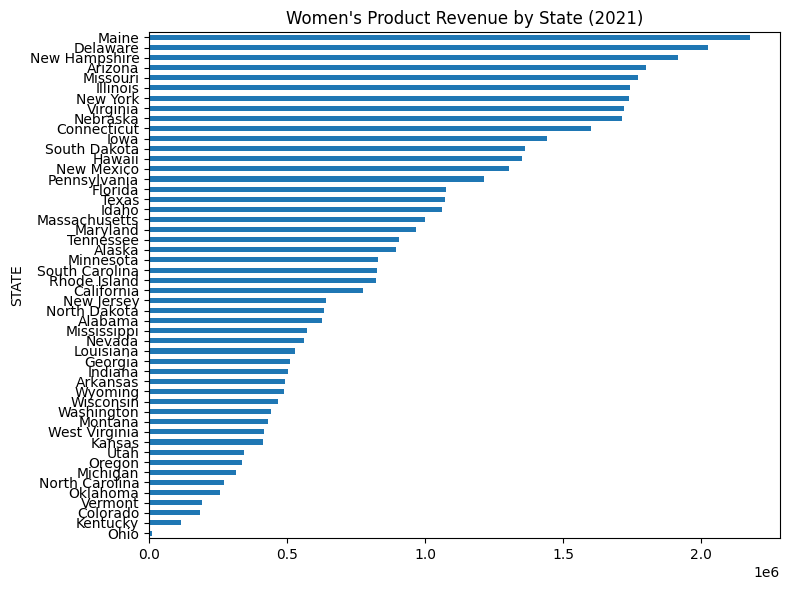

In [81]:
# Chart 6 State Revenue
state_sales.sort_values().plot(
    kind='barh',
    figsize=(8,6)
)

plt.title("Women's Product Revenue by State (2021)")
plt.tight_layout()

## Showing all 50 states is too crowded. Simplifying down to top 10.

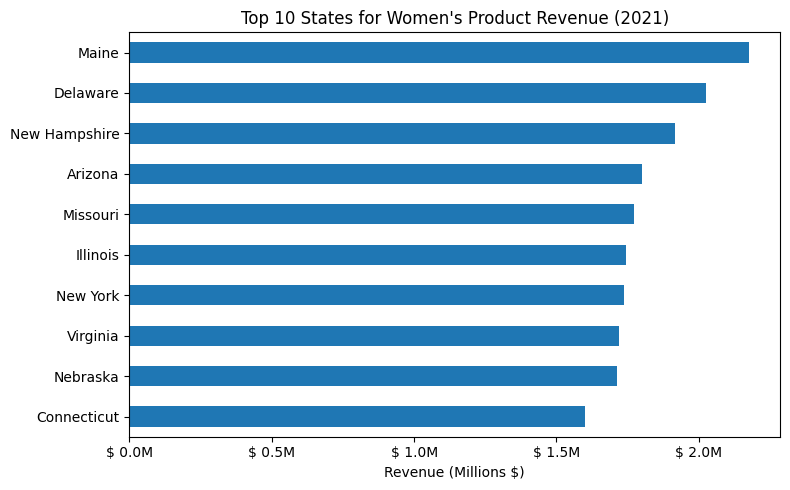

In [82]:
# Top 10 states for women's product revenue in 2021
top10_state_sales = state_sales.nlargest(10)

top10_state_sales.sort_values().plot(
    kind='barh',
    figsize=(8,5)
)
plt.title("Top 10 States for Women's Product Revenue (2021)")
plt.xlabel('Revenue (Millions $)')
plt.ylabel('')

plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'${x/1_000_000: .1f}M'))
plt.tight_layout()
plt.savefig('images/chart6_top10_womens_revenue_2021.png', dpi=300, bbox_inches='tight')
plt.show()




## Downloading all created images in a zip file

In [83]:
# Downloading images
import shutil

shutil.make_archive('Rush_Sales_Charts', 'zip', 'images')

'/content/Rush_Sales_Charts.zip'

In [84]:
# Saving images to computer
from google.colab import files

files.download('Rush_Sales_Charts.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Looking to understand the sales method performance year over year


In [85]:
# Revenue by sales method and year
sales_method_yoy = pd.pivot_table(
    combined_df,
    index='SALES_METHOD',
    columns=combined_df['INVOICE_DATE'].dt.year,
    values='REVENUE',
    aggfunc='sum'
)

sales_method_yoy

INVOICE_DATE,2020,2021
SALES_METHOD,,
In-store,9373500.0,26274075.0
Online,4519966.0,42445166.0
Outlet,10327059.0,29437416.0


In [86]:
# Dollar growth
sales_method_yoy['Growth ($)'] = sales_method_yoy[2021] - sales_method_yoy[2020]

# Percent growth
sales_method_yoy['Growth (%)'] = (
    (sales_method_yoy[2021] - sales_method_yoy[2020])
    / sales_method_yoy[2020] * 100
).round(2)

sales_method_yoy.sort_values('Growth ($)', ascending=False)

INVOICE_DATE,2020,2021,Growth ($),Growth (%)
SALES_METHOD,,,,
Online,4519966.0,42445166.0,37925200.0,839.06
Outlet,10327059.0,29437416.0,19110357.0,185.05
In-store,9373500.0,26274075.0,16900575.0,180.30


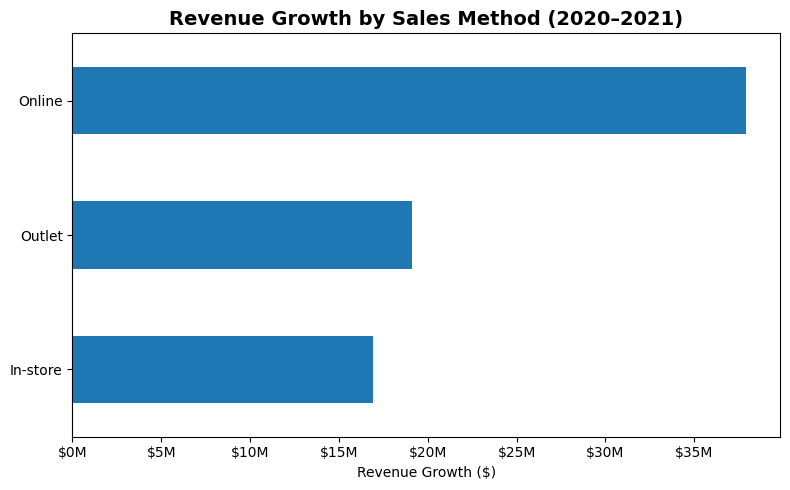

In [87]:
# Creat a chart showing sales method dollar growth
sales_method_yoy['Growth ($)'].sort_values().plot(
    kind='barh',
    figsize=(8,5)
)

plt.title('Revenue Growth by Sales Method (2020–2021)', fontsize=14, weight='bold')
plt.xlabel('Revenue Growth ($)')
plt.ylabel('')
plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'${x/1_000_000:.0f}M'))
plt.tight_layout()
plt.savefig(
    'Chart_7_Sales_Method_Growth.png',
    dpi=300,
    bbox_inches='tight')
plt.show()

## Add new chart to the zip file

In [92]:
import shutil
shutil.make_archive(
    'Rush_Sales_Charts_v2',
    'zip',
    'images'
)

from google.colab import files
files.download('Rush_Sales_Charts_v2.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [93]:
import os

print("Images folder:")
print(os.listdir('images'))

print("\nContent folder:")
print(os.listdir())

Images folder:
['chart5_retailer_product_mix.png', 'chart2_product_growth.png', 'chart6_top10_womens_revenue_2021.png', 'chart3_retailer_revenue_growth.png', 'chart1_product_revenue_2021.png', 'chart4_retailer_revenue_by_year.png']

Content folder:
['.config', 'images', 'Chart_7_Sales_Method_Growth.png', 'Rush_Sales_Charts_v2.zip', 'Rush_Sales_Charts.zip', 'sample_data']


In [94]:
import shutil

shutil.make_archive(
    'Rush_Sales_Charts_v2',
    'zip',
    'images'
)

'/content/Rush_Sales_Charts_v2.zip'

In [95]:
from google.colab import files

files.download('Rush_Sales_Charts_v2.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [96]:
import shutil
shutil.copy('Chart_7_Sales_Method_Growth.png', 'images/Chart_7_Sales_Method_Growth.png')

'images/Chart_7_Sales_Method_Growth.png'

In [97]:
import os

os.listdir('images')

['chart5_retailer_product_mix.png',
 'chart2_product_growth.png',
 'chart6_top10_womens_revenue_2021.png',
 'chart3_retailer_revenue_growth.png',
 'chart1_product_revenue_2021.png',
 'Chart_7_Sales_Method_Growth.png',
 'chart4_retailer_revenue_by_year.png']

In [98]:
shutil.make_archive('Rush_Sales_Charts_v3', 'zip', 'images')

'/content/Rush_Sales_Charts_v3.zip'

In [99]:
from google.colab import files

files.download('Rush_Sales_Charts_v3.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>